In [ ]:
import pandas as pd
import os
import glob

folder = r"C:\Users\amira\Downloads\SUC1dataset"
files = glob.glob(os.path.join(folder, "*.csv"))

dfs = []

for f in files:
    name = os.path.basename(f)


    if "Measurements" not in name:
        continue

    print("Loading:", name)
    df = pd.read_csv(f)

   
    if "time_datetime" in df.columns:
        df["time_datetime"] = pd.to_datetime(df["time_datetime"])

    # label
    if "Error" in df.columns:
        df["attack"] = df["Error"].astype(int)
        df = df.drop(columns=["Error"])
    else:
        df["attack"] = 0

 
    scenario = name.split("_")[2]   # S1 S2 S3 S4
    df["scenario"] = scenario

   
    if scenario in ["S1","S2"]:
        df["attack_type"] = "physics"
    elif scenario == "S3":
        df["attack_type"] = "control"
    elif scenario == "S4":
        df["attack_type"] = "network"

    dfs.append(df)

dataset = pd.concat(dfs, ignore_index=True)

print("\nFinal combined shape:", dataset.shape)
print(dataset["scenario"].value_counts())
print(dataset["attack"].value_counts())


Loading: Electron_SUC1_S1_Pwind_Attack_Measurements.csv
Loading: Electron_SUC1_S2_Pbss_meas_Attack_Measurements.csv
Loading: Electron_SUC1_S3_Pbss_ref_Attack_Measurements.csv
Loading: Electron_SUC1_S4_Modbus_MITM_Attack_Measurements.csv

Final combined shape: (797, 14)
scenario
S1    242
S2    206
S3    205
S4    144
Name: count, dtype: int64
attack
0    781
1     16
Name: count, dtype: int64


C:\Users\amira\AppData\Local\Temp\ipykernel_33528\1575558303.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time_datetime"] = pd.to_datetime(df["time_datetime"])


In [7]:
out = r"C:\Users\amira\Downloads\SUC1dataset\combined_measurements.csv"
dataset.to_csv(out, index=False)
print("Saved:", out)


Saved: C:\Users\amira\Downloads\SUC1dataset\combined_measurements.csv


In [8]:
dataset.groupby(["scenario","attack"]).size()


scenario  attack
S1        0         242
S2        0         206
S3        0         205
S4        0         128
          1          16
dtype: int64

In [9]:
import pandas as pd

df = dataset.copy()

print("\nDataset shape:", df.shape)
print("\nFeatures:", list(df.columns))

print("\nAttack ratio:", df["attack"].mean())

print("\nAttacks per scenario:")
print(df.groupby("scenario")["attack"].sum())

print("\nDuration per scenario:")
print(df.groupby("scenario")["time_datetime"].agg(["min","max"]))



Dataset shape: (797, 14)

Features: ['time_datetime', 'Pbss', 'Pbss_bus8_Bus8_bTX', 'Pbss_bus8_real', 'Pbss_bus8_ref_real', 'Pbss_ref', 'Phres', 'Phres_real', 'Phres_ref', 'Ptot_wind1_real', 'Pwind', 'attack', 'scenario', 'attack_type']

Attack ratio: 0.020075282308657464

Attacks per scenario:
scenario
S1     0
S2     0
S3     0
S4    16
Name: attack, dtype: int64

Duration per scenario:
                         min                 max
scenario                                        
S1       2024-05-17 15:43:01 2024-05-17 16:05:04
S2       2024-05-24 05:38:29 2024-05-24 05:57:12
S3       2026-02-13 15:45:50 2026-02-13 16:04:25
S4       2024-05-20 11:39:37 2024-05-20 11:58:26


In [ ]:


import pandas as pd

df = dataset.copy()
df["time_datetime"] = pd.to_datetime(df["time_datetime"], format="%d-%b-%Y %H:%M:%S", errors="coerce")
df = df.sort_values(["scenario", "time_datetime"])

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nSamples per scenario:")
print(df["scenario"].value_counts())

print("\nAttack counts per scenario:")
print(df.groupby("scenario")["attack"].sum())

print("\nOverall attack ratio:", df["attack"].mean())


sampling = df.groupby("scenario")["time_datetime"].diff().dt.total_seconds()
print("\nSampling interval per scenario (seconds):")
print(sampling.groupby(df["scenario"]).describe())


Dataset shape: (797, 14)

Columns: ['time_datetime', 'Pbss', 'Pbss_bus8_Bus8_bTX', 'Pbss_bus8_real', 'Pbss_bus8_ref_real', 'Pbss_ref', 'Phres', 'Phres_real', 'Phres_ref', 'Ptot_wind1_real', 'Pwind', 'attack', 'scenario', 'attack_type']

Samples per scenario:
scenario
S1    242
S2    206
S3    205
S4    144
Name: count, dtype: int64

Attack counts per scenario:
scenario
S1     0
S2     0
S3     0
S4    16
Name: attack, dtype: int64

Overall attack ratio: 0.020075282308657464

Sampling interval per scenario (seconds):
          count      mean       std  min  25%  50%  75%   max
scenario                                                     
S1        241.0  5.489627  0.509183  5.0  5.0  5.0  6.0   7.0
S2        205.0  5.478049  0.510436  5.0  5.0  5.0  6.0   7.0
S3        204.0  5.465686  0.509804  5.0  5.0  5.0  6.0   7.0
S4        143.0  7.895105  7.574711  5.0  5.0  5.0  6.0  58.0


In [ ]:


def feature_role(col: str) -> str:
    c = col.lower()
    if c in ["attack", "scenario", "attack_type", "time_datetime"]:
        return "metadata/label"
    if "ref" in c:
        return "controller reference (setpoint)"
    if "real" in c:
        return "physical measurement (sensor)"
    if "btx" in c:
        return "control/communication parameter"
    if c in ["pbss", "phres", "pwind"]:
        return "internal/control variable"
    return "other"

feature_info = pd.DataFrame({
    "feature": df.columns,
    "role": [feature_role(c) for c in df.columns]
})

print(feature_info)


               feature                             role
0        time_datetime                   metadata/label
1                 Pbss        internal/control variable
2   Pbss_bus8_Bus8_bTX  control/communication parameter
3       Pbss_bus8_real    physical measurement (sensor)
4   Pbss_bus8_ref_real  controller reference (setpoint)
5             Pbss_ref  controller reference (setpoint)
6                Phres        internal/control variable
7           Phres_real    physical measurement (sensor)
8            Phres_ref  controller reference (setpoint)
9      Ptot_wind1_real    physical measurement (sensor)
10               Pwind        internal/control variable
11              attack                   metadata/label
12            scenario                   metadata/label
13         attack_type                   metadata/label


Numeric feature summary (all data):
                Pbss  Pbss_bus8_Bus8_bTX  Pbss_bus8_real  Pbss_bus8_ref_real  \
count     797.000000          797.000000      797.000000          797.000000   
mean     -667.931821           -1.851773    -1647.698048        -3963.385155   
std     64246.491367           20.809937    13877.360918        56641.785930   
min   -387570.687500          -57.616509   -38858.257147      -298799.570312   
25%     -2587.113037           -3.307150    -2596.156257        -2212.220459   
50%       965.278137            1.990643      899.224850         1317.497192   
75%      3553.088623            5.428989     3197.681703         3608.714600   
max    387992.093750           60.467955    39100.237932       381915.039062   

            Pbss_ref          Phres    Phres_real    Phres_ref  \
count     797.000000     797.000000    797.000000   797.000000   
mean    -7571.351355    5638.381884   3222.620028  5597.239649   
std     45716.809491   63976.573286  13770.19

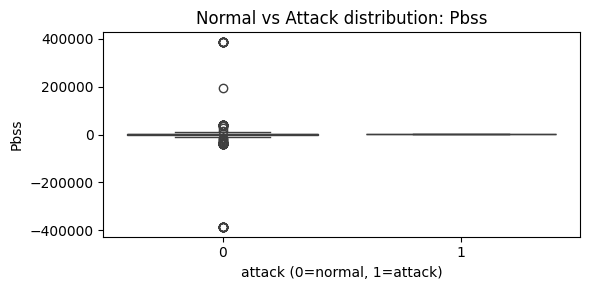

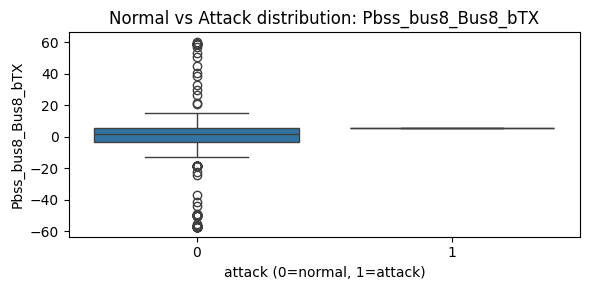

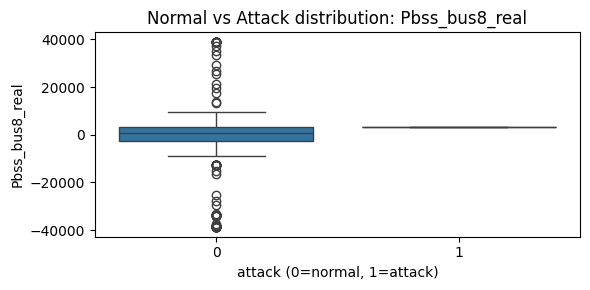

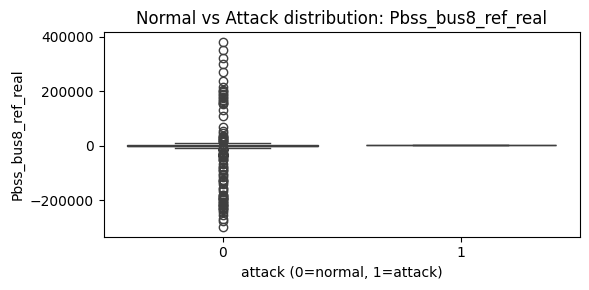

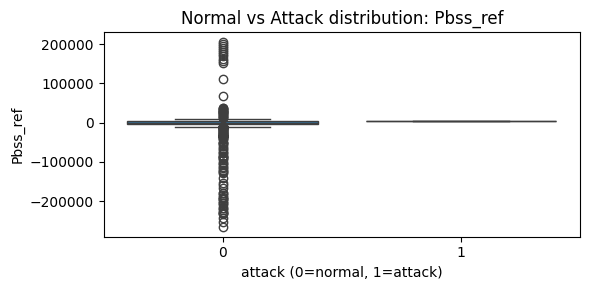

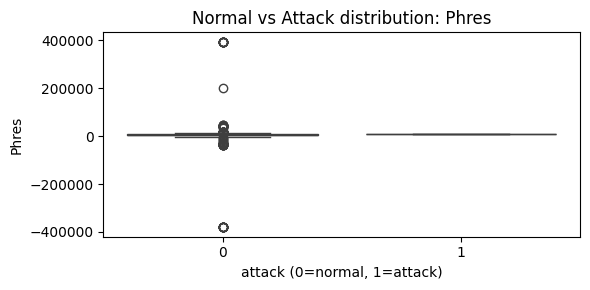

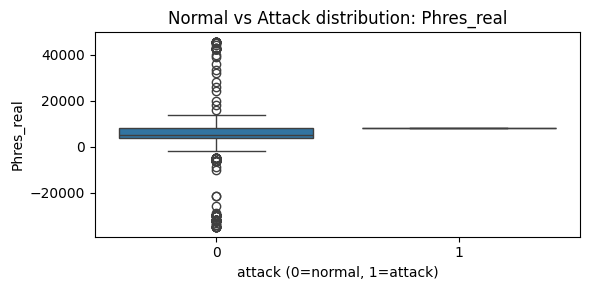

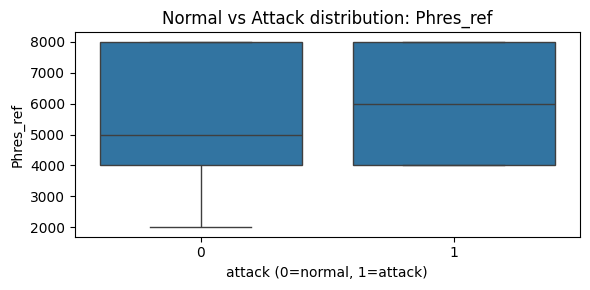

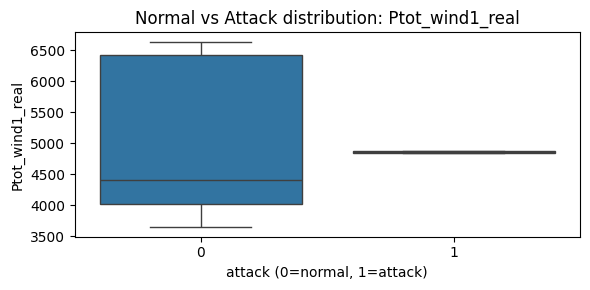

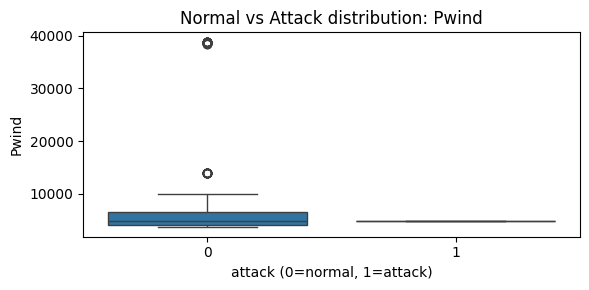

In [ ]:


import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [c for c in df.select_dtypes(include="number").columns if c != "attack"]

print("Numeric feature summary (all data):")
print(df[numeric_cols].describe())

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df["attack"], y=df[col])
    plt.title(f"Normal vs Attack distribution: {col}")
    plt.xlabel("attack (0=normal, 1=attack)")
    plt.tight_layout()
    plt.show()


Residual stats grouped by attack:
            Pbss_err                                 Phres_err                \
                mean           std            max         mean           std   
attack                                                                         
0       12540.718439  44635.001063  343114.508282  6010.114046  12351.659962   
1         415.711170      5.182094     423.127129  2027.973216   2075.446722   

                         Wind_err                             
                 max         mean          std           max  
attack                                                        
0       43036.795774  1467.722313  6112.704337  35002.684499  
1        4051.207559    23.133117    12.582904     42.971126  


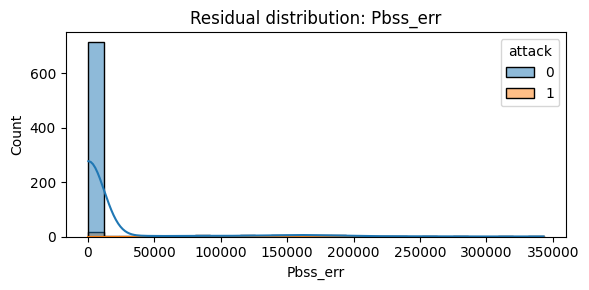

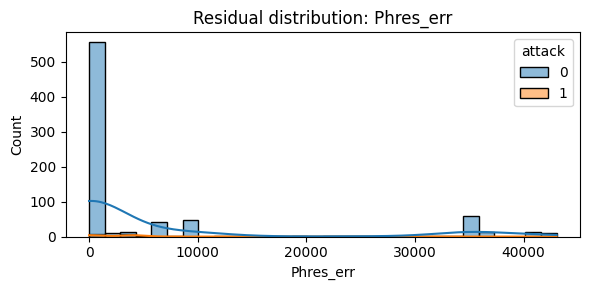

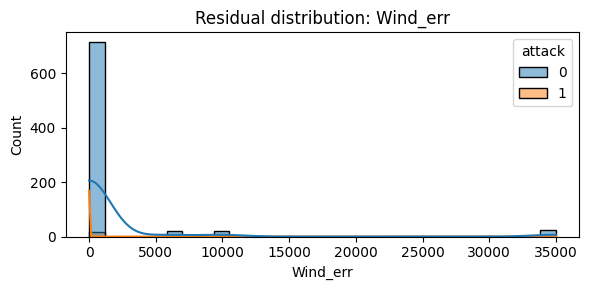

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns


df["Pbss_err"] = (df["Pbss_bus8_real"] - df["Pbss_bus8_ref_real"]).abs()
df["Phres_err"] = (df["Phres_real"] - df["Phres_ref"]).abs()
df["Wind_err"] = (df["Ptot_wind1_real"] - df["Pwind"]).abs()

print("Residual stats grouped by attack:")
print(df.groupby("attack")[["Pbss_err", "Phres_err", "Wind_err"]].agg(["mean", "std", "max"]))

# Visualize residual distributions
for col in ["Pbss_err", "Phres_err", "Wind_err"]:
    plt.figure(figsize=(6,3))
    sns.histplot(data=df, x=col, hue="attack", bins=30, kde=True)
    plt.title(f"Residual distribution: {col}")
    plt.tight_layout()
    plt.show()


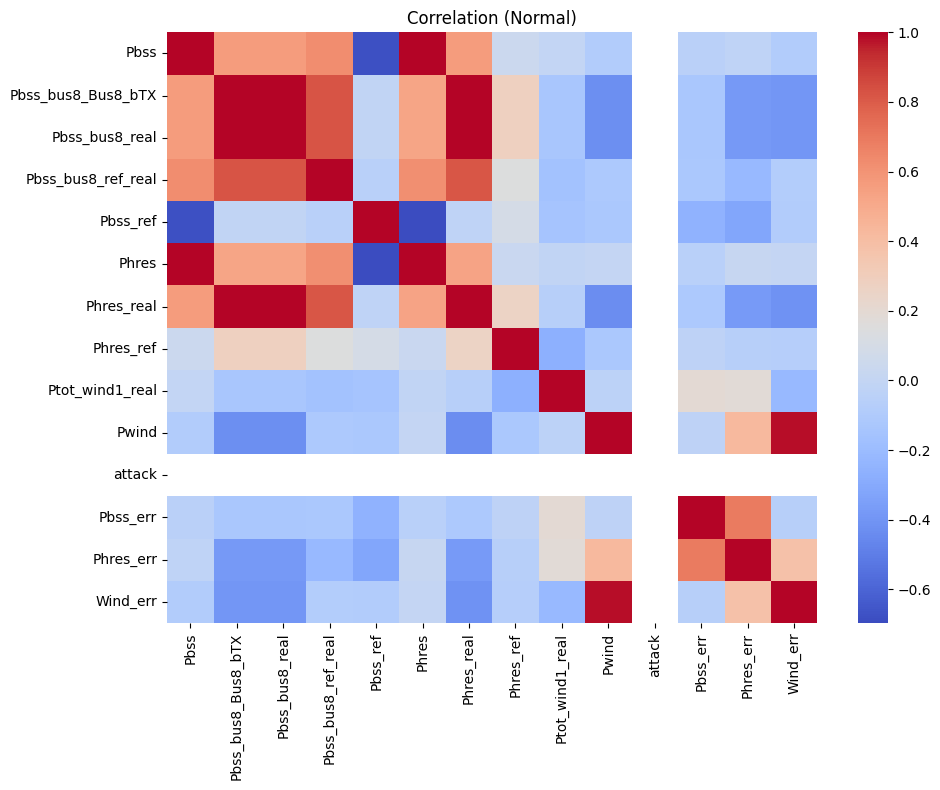

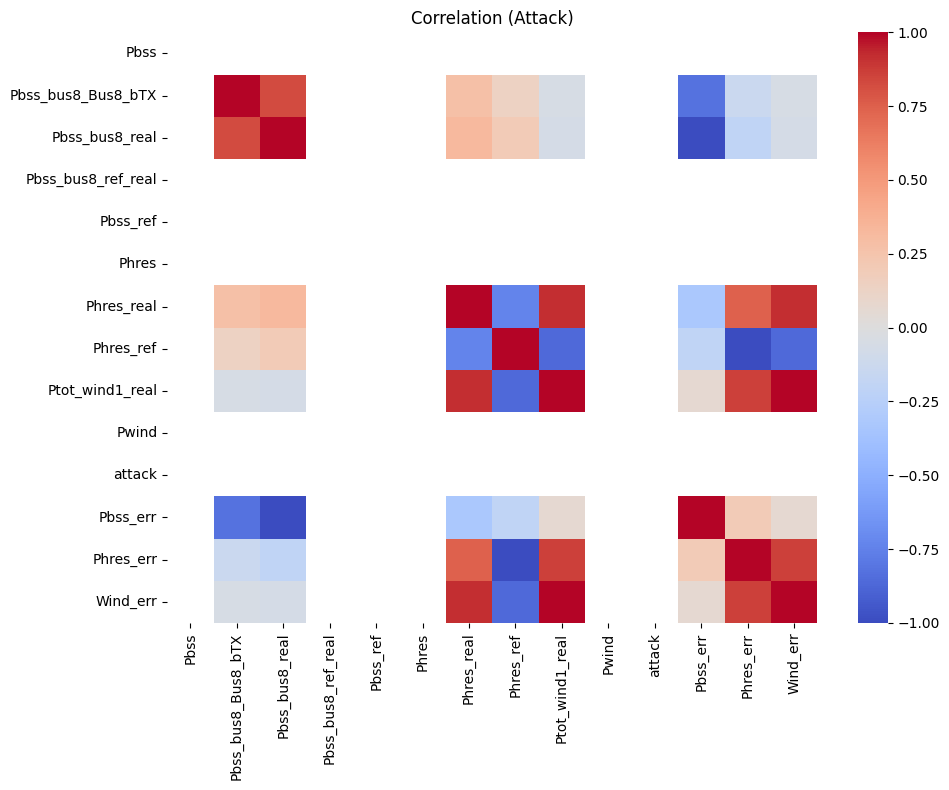

In [ ]:


import seaborn as sns
import matplotlib.pyplot as plt

normal = df[df["attack"] == 0]
attack = df[df["attack"] == 1]

normal_corr = normal.corr(numeric_only=True)
attack_corr = attack.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(normal_corr, cmap="coolwarm")
plt.title("Correlation (Normal)")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,8))
sns.heatmap(attack_corr, cmap="coolwarm")
plt.title("Correlation (Attack)")
plt.tight_layout()
plt.show()


Top 15 important features:
Phres_real            0.193029
Wind_err              0.159003
Phres                 0.125093
Pbss_ref              0.113711
Ptot_wind1_real       0.091684
Pbss_bus8_ref_real    0.080089
Pbss_bus8_real        0.077159
Pbss_bus8_Bus8_bTX    0.058900
Pbss                  0.055422
Pwind                 0.037937
Pbss_err              0.004291
Phres_err             0.003533
Phres_ref             0.000147
dtype: float64


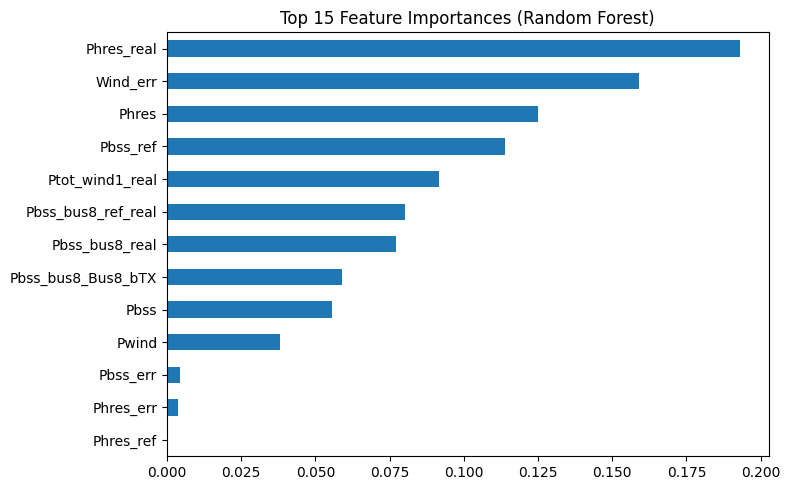

In [ ]:


from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Build X/y
X = df.select_dtypes(include="number").drop(columns=["attack"])
y = df["attack"].astype(int)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced" 
)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 15 important features:")
print(importance.head(15))

plt.figure(figsize=(8,5))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()
